# ЛАБОРАТОРНАЯ РАБОТА 4 - ПРОГНОЗИРОВАНИЕ ТОВАРООБОРОТА

## Подготовка данных (загрузка и разделение)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.api import SimpleExpSmoothing
from sklearn.metrics import mean_squared_error

df = pd.read_csv('tovar_moving.csv', index_col=['date'], parse_dates=['date'])
print("Первые 5 строк данных:")
print(df.head())
print("\nИнформация о данных:")
print(df.info())


test_df = df.iloc[-1:]
train_df = df.iloc[:-1]

print(f"\nРазмер обучающей выборки: {len(train_df)}")
print(f"Размер тестовой выборки: {len(test_df)}")
print(f"Значение в тестовой выборке: {test_df['qty'].values[0]}")

Первые 5 строк данных:
                 qty
date                
2009-12-25   72314.0
2009-12-26   66586.0
2009-12-27  125199.0
2009-12-28   91544.0
2009-12-29   76995.0

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1439 entries, 2009-12-25 to 2013-12-02
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   qty     1439 non-null   float64
dtypes: float64(1)
memory usage: 22.5 KB
None

Размер обучающей выборки: 1438
Размер тестовой выборки: 1
Значение в тестовой выборке: 423846.0


## Анализ тренда и сезонности

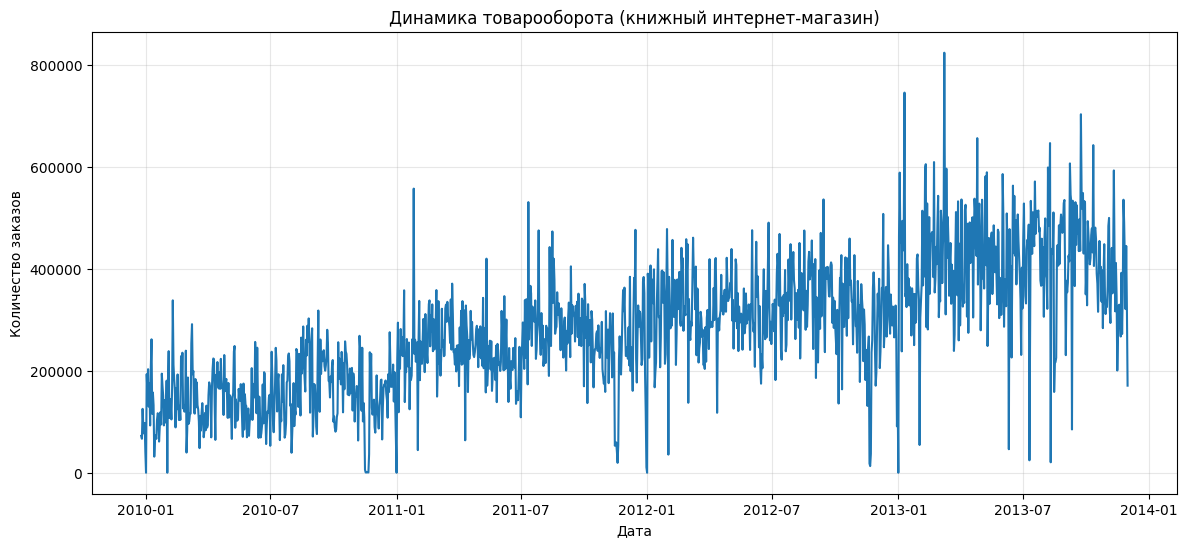

Индекс не имеет частоты. Устанавливаем ежедневную частоту...
После переиндексации: 1438 записей


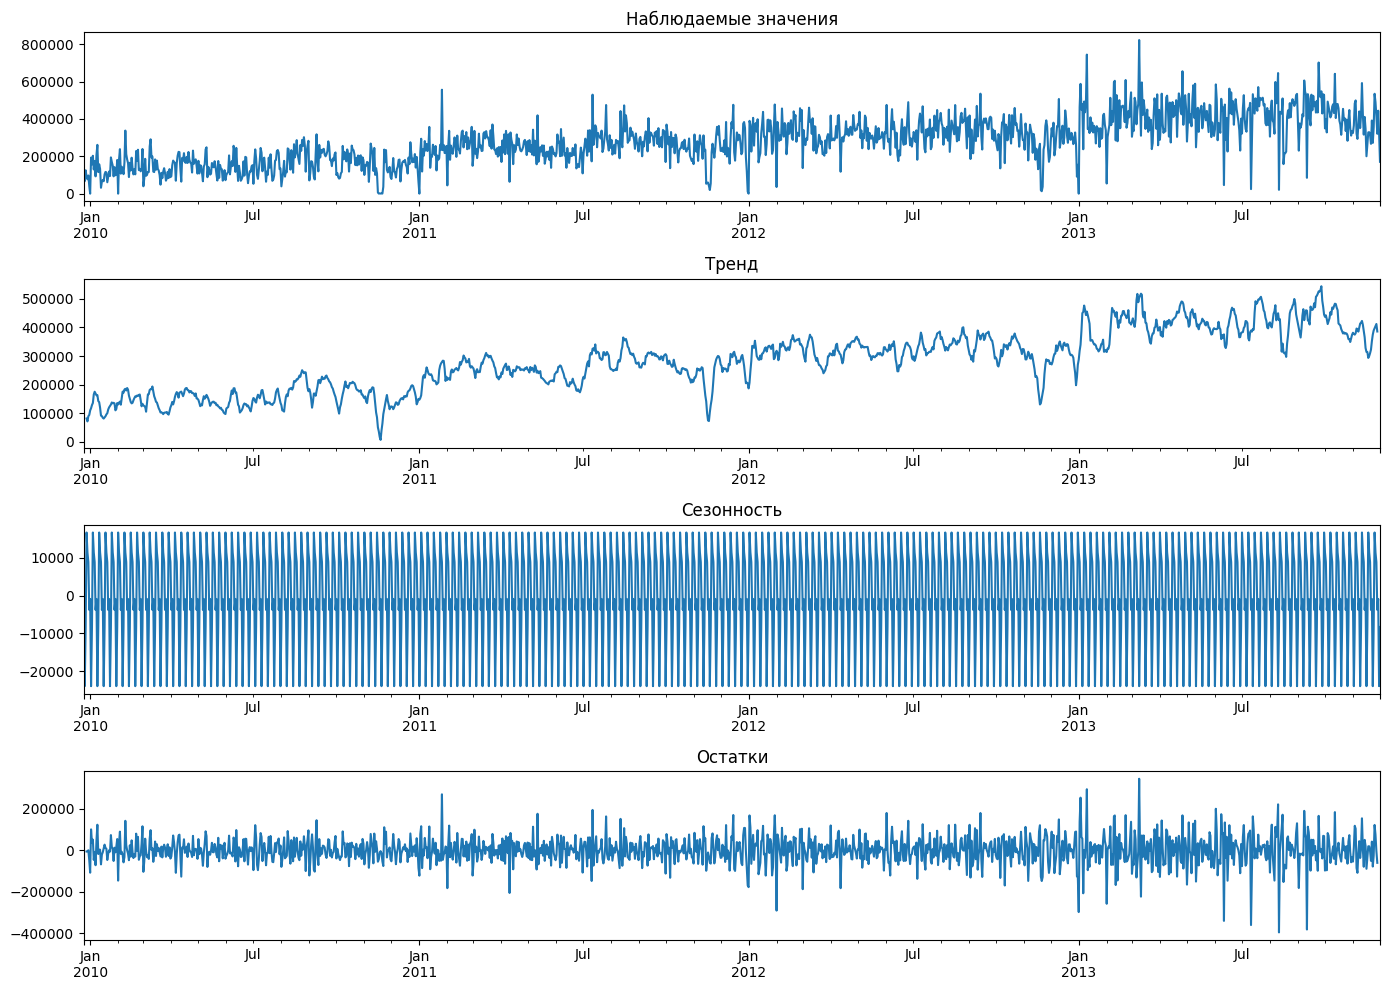

In [4]:
plt.figure(figsize=(14, 6))
plt.plot(train_df.index, train_df['qty'], linewidth=1.5)
plt.title('Динамика товарооборота (книжный интернет-магазин)')
plt.xlabel('Дата')
plt.ylabel('Количество заказов')
plt.grid(True, alpha=0.3)
plt.show()


try:

    if train_df.index.freq is None:
        print("Индекс не имеет частоты. Устанавливаем ежедневную частоту...")

        full_index = pd.date_range(start=train_df.index.min(),
                                   end=train_df.index.max(),
                                   freq='D')

        train_df = train_df.reindex(full_index)

        train_df['qty'] = train_df['qty'].interpolate()
        print(f"После переиндексации: {len(train_df)} записей")

    decomposition = seasonal_decompose(train_df['qty'], model='additive', period=7)

    fig, axes = plt.subplots(4, 1, figsize=(14, 10))
    decomposition.observed.plot(ax=axes[0], title='Наблюдаемые значения')
    decomposition.trend.plot(ax=axes[1], title='Тренд')
    decomposition.seasonal.plot(ax=axes[2], title='Сезонность')
    decomposition.resid.plot(ax=axes[3], title='Остатки')
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Ошибка при декомпозиции: {e}")
    print("Попробуйте другой период или проверьте данные.")

## Экспоненциальное сглаживание

In [5]:
print("ЭКСПОНЕНЦИАЛЬНОЕ СГЛАЖИВАНИЕ")


ses = SimpleExpSmoothing(train_df['qty'])
alpha = 0.7
model_ses = ses.fit(smoothing_level=alpha, optimized=False)
exp_pred = model_ses.forecast(1)

actual_value = test_df['qty'].values[0]
exp_mse = mean_squared_error([actual_value], [exp_pred.values[0]])

print(f"Прогноз экспоненциального сглаживания (alpha=0.7): {exp_pred.values[0]:.3f}")
print(f"Фактическое значение: {actual_value:.3f}")
print(f"Абсолютная ошибка: {abs(exp_pred.values[0] - actual_value):.3f}")
print(f"MSE: {exp_mse:.3f}")

ЭКСПОНЕНЦИАЛЬНОЕ СГЛАЖИВАНИЕ
Прогноз экспоненциального сглаживания (alpha=0.7): 225015.523
Фактическое значение: 423846.000
Абсолютная ошибка: 198830.477
MSE: 39533558724.370


## Проверка на стационарность

In [6]:
def adf_test(series, series_name="Ряд"):
    print(f"\n--- Тест Дики-Фуллера для: {series_name} ---")
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {value:.6f}')

    if result[1] <= 0.05:
        print(" Ряд СТАЦИОНАРЕН (отвергаем гипотезу о наличии единичного корня)")
        return True
    else:
        print(" Ряд НЕ СТАЦИОНАРЕН (есть единичный корень)")
        return False



print("ПРОВЕРКА СТАЦИОНАРНОСТИ")


is_stationary = adf_test(train_df['qty'], "Исходный ряд")


d = 0
current_series = train_df['qty'].copy()

if not is_stationary:
    print("\nРяд нестационарен. Берем первую разность...")
    diff1 = train_df['qty'].diff().dropna()
    is_stationary_diff1 = adf_test(diff1, "Первая разность")

    if is_stationary_diff1:
        d = 1
        print(f"\n Порядок интегрирования d = {d}")
        current_series = diff1
    else:
        print("\nБерем вторую разность...")
        diff2 = diff1.diff().dropna()
        is_stationary_diff2 = adf_test(diff2, "Вторая разность")
        if is_stationary_diff2:
            d = 2
            print(f"\n Порядок интегрирования d = {d}")
            current_series = diff2
        else:
            print("\n Ряд не становится стационарным. Возможно, нужны другие методы.")
else:
    print(f"\n Ряд стационарен. Порядок интегрирования d = {d}")

ПРОВЕРКА СТАЦИОНАРНОСТИ

--- Тест Дики-Фуллера для: Исходный ряд ---
ADF Statistic: -2.255303
p-value: 0.186789
Critical Values:
   1%: -3.434973
   5%: -2.863582
   10%: -2.567857
 Ряд НЕ СТАЦИОНАРЕН (есть единичный корень)

Ряд нестационарен. Берем первую разность...

--- Тест Дики-Фуллера для: Первая разность ---
ADF Statistic: -13.780727
p-value: 0.000000
Critical Values:
   1%: -3.434973
   5%: -2.863582
   10%: -2.567857
 Ряд СТАЦИОНАРЕН (отвергаем гипотезу о наличии единичного корня)

 Порядок интегрирования d = 1


## Определение порядка AR

ОПРЕДЕЛЕНИЕ ПОРЯДКА МОДЕЛИ AR


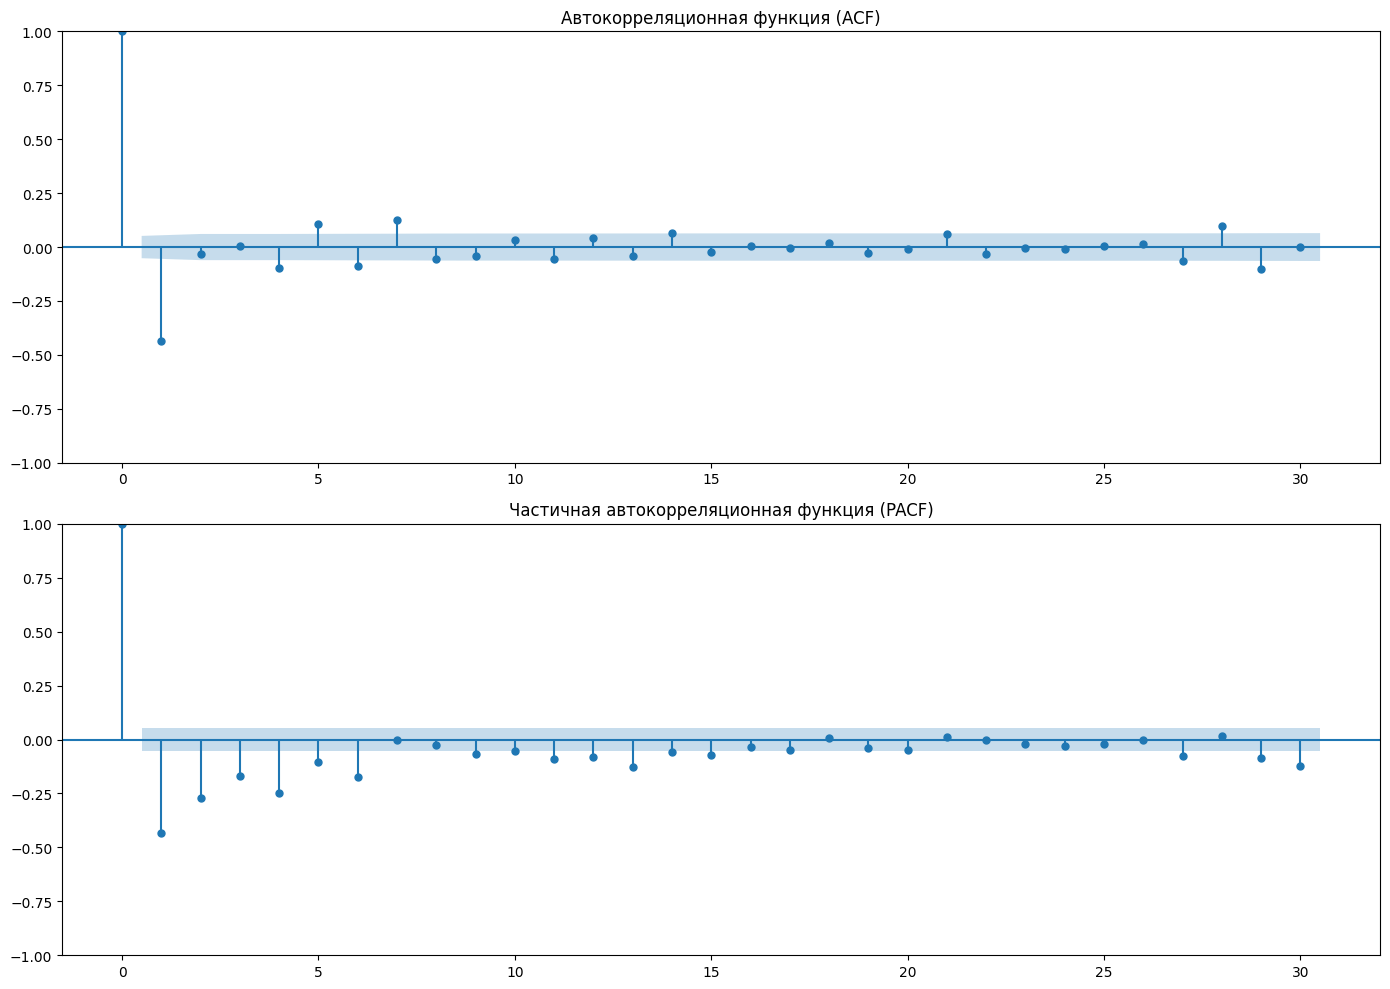


 Анализ PACF:
Определите p по последнему значимому лагу (выходящему за голубую зону)
Рекомендация: обычно p = последний значимый лаг на PACF

Выбранный порядок модели: p = 0


In [8]:
print("ОПРЕДЕЛЕНИЕ ПОРЯДКА МОДЕЛИ AR")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Используем стационарный ряд для PACF
series_for_pacf = current_series if d > 0 else train_df['qty']

plot_acf(series_for_pacf, ax=ax1, lags=30, title='Автокорреляционная функция (ACF)')
plot_pacf(series_for_pacf, ax=ax2, lags=30, title='Частичная автокорреляционная функция (PACF)')

plt.tight_layout()
plt.show()

print("\n Анализ PACF:")
print("Определите p по последнему значимому лагу (выходящему за голубую зону)")
print("Рекомендация: обычно p = последний значимый лаг на PACF")

p = 0

print(f"\nВыбранный порядок модели: p = {p}")

## Построение модели AR и прогноз

In [9]:
print("МОДЕЛЬ АВТОРЕГРЕССИИ AR(p)")

ar_model = AutoReg(train_df['qty'], lags=p).fit()
print(ar_model.summary())

ar_pred = ar_model.predict(start=len(train_df), end=len(train_df), dynamic=False)

actual_value = test_df['qty'].values[0]
ar_mse = mean_squared_error([actual_value], [ar_pred.values[0]])

print(f"\nПрогноз модели AR(p={p}): {ar_pred.values[0]:.3f}")
print(f"Фактическое значение: {actual_value:.3f}")
print(f"Абсолютная ошибка: {abs(ar_pred.values[0] - actual_value):.3f}")
print(f"MSE: {ar_mse:.3f}")

МОДЕЛЬ АВТОРЕГРЕССИИ AR(p)
                            AutoReg Model Results                             
Dep. Variable:                    qty   No. Observations:                 1438
Model:                     AutoReg(0)   Log Likelihood              -18917.832
Method:               Conditional MLE   S.D. of innovations         125080.924
Date:                Wed, 24 Jun 2026   AIC                          37839.663
Time:                        14:04:17   BIC                          37850.205
Sample:                    12-25-2009   HQIC                         37843.599
                         - 12-01-2013                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.814e+05   3298.463     85.309      0.000    2.75e+05    2.88e+05

Прогноз модели AR(p=0): 281388.925
Фактическое значение: 423846.000
Абсолютная ошибка: 142457.075
MSE: 

## Сравнение результатов

In [10]:
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ ПРОГНОЗИРОВАНИЯ")


results = pd.DataFrame({
    'Метод': ['Экспоненциальное сглаживание (α=0.7)', f'Авторегрессия AR({p})'],
    'Прогноз': [exp_pred.values[0], ar_pred.values[0]],
    'Факт': [actual_value, actual_value],
    'Абсолютная ошибка': [abs(exp_pred.values[0] - actual_value),
                          abs(ar_pred.values[0] - actual_value)],
    'MSE': [exp_mse, ar_mse]
})

print(results.to_string(index=False))


print("ВЫВОДЫ")

if exp_mse < ar_mse:
    print("Лучший результат показало ЭКСПОНЕНЦИАЛЬНОЕ СГЛАЖИВАНИЕ")
    print(f"   (MSE: {exp_mse:.4f} против {ar_mse:.4f} у AR)")
else:
    print("Лучший результат показала МОДЕЛЬ АВТОРЕГРЕССИИ")
    print(f"   (MSE: {ar_mse:.4f} против {exp_mse:.4f} у эксп. сглаживания)")


print("\nДополнительный анализ:")
print(f"Среднее значение ряда: {train_df['qty'].mean():.3f}")
print(f"Последнее значение ряда: {train_df['qty'].iloc[-1]:.3f}")
print(f"Случайное угадывание (последнее значение): ошибка = {abs(train_df['qty'].iloc[-1] - actual_value):.3f}")

СРАВНЕНИЕ РЕЗУЛЬТАТОВ ПРОГНОЗИРОВАНИЯ
                               Метод       Прогноз     Факт  Абсолютная ошибка          MSE
Экспоненциальное сглаживание (α=0.7) 225015.522647 423846.0      198830.477353 3.953356e+10
                 Авторегрессия AR(0) 281388.924896 423846.0      142457.075104 2.029402e+10
ВЫВОДЫ
Лучший результат показала МОДЕЛЬ АВТОРЕГРЕССИИ
   (MSE: 20294018247.2755 против 39533558724.3703 у эксп. сглаживания)

Дополнительный анализ:
Среднее значение ряда: 281388.925
Последнее значение ряда: 170665.000
Случайное угадывание (последнее значение): ошибка = 253181.000


## Визуализация прогнозов

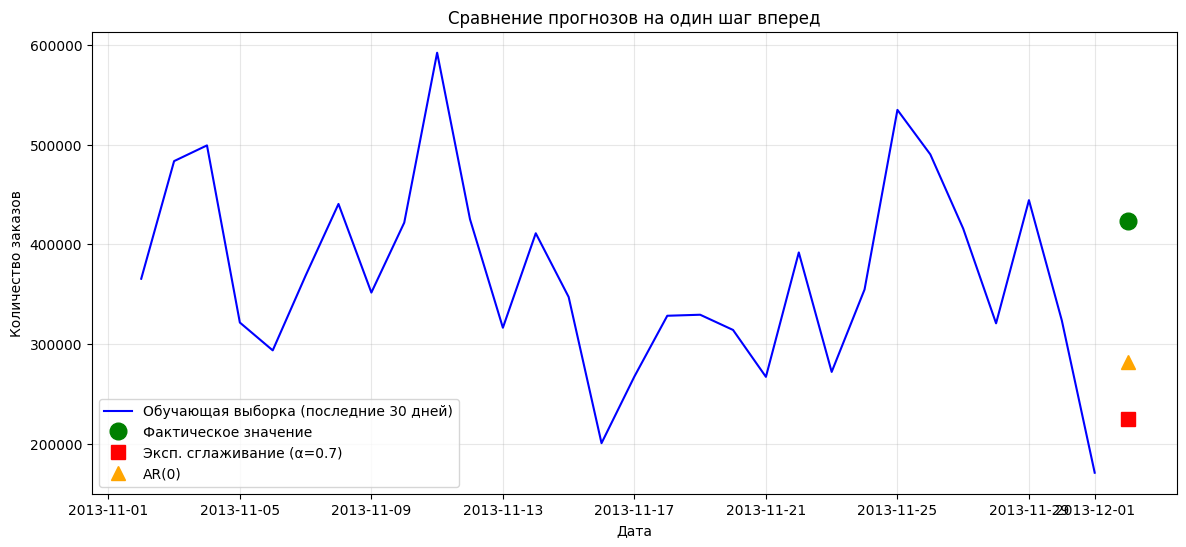

СВОДНАЯ СТАТИСТИКА ДАННЫХ
Количество наблюдений: 1439
Минимальное значение: 0.00
Максимальное значение: 823230.00
Среднее значение: 281487.92
Медиана: 280225.00
Стандартное отклонение: 125137.29


In [11]:
plt.figure(figsize=(14, 6))

# График обучающей выборки
plt.plot(train_df.index[-30:], train_df['qty'].values[-30:],
         label='Обучающая выборка (последние 30 дней)',
         color='blue', linewidth=1.5)

# Добавляем фактическое значение
plt.plot(test_df.index, test_df['qty'].values,
         'o', color='green', markersize=12, label='Фактическое значение')

# Добавляем прогнозы
plt.plot(test_df.index, exp_pred.values,
         's', color='red', markersize=10, label=f'Эксп. сглаживание (α=0.7)')

plt.plot(test_df.index, ar_pred.values,
         '^', color='orange', markersize=10, label=f'AR({p})')

plt.title('Сравнение прогнозов на один шаг вперед')
plt.xlabel('Дата')
plt.ylabel('Количество заказов')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


print("СВОДНАЯ СТАТИСТИКА ДАННЫХ")

print(f"Количество наблюдений: {len(df)}")
print(f"Минимальное значение: {df['qty'].min():.2f}")
print(f"Максимальное значение: {df['qty'].max():.2f}")
print(f"Среднее значение: {df['qty'].mean():.2f}")
print(f"Медиана: {df['qty'].median():.2f}")
print(f"Стандартное отклонение: {df['qty'].std():.2f}")